# Multiple Type Experiment

In [1]:
import warnings;
warnings.filterwarnings('ignore');

from time import sleep
from tqdm.auto import tqdm

import sys
import importlib
import numpy as np
import nbformat
# import plotly.express
# import plotly.express as px
import pandas as pd
import cvxpy as cp
import scipy.optimize as optimization
import matplotlib.pyplot as plt
import seaborn as sns

### Confidence Scaling

In [2]:
cthresh = 1
clow = np.sqrt(2)

### CVXPY Code

In [3]:
def generate_cvxpy_solve(num_types, num_resources):
    x = cp.Variable(shape=(num_types,num_resources))

    sizes = cp.Parameter(num_types, nonneg=True)
    weights = cp.Parameter((num_types, num_resources), nonneg=True)
    budget = cp.Parameter(num_resources, nonneg=True)


    objective = cp.Maximize(cp.log(cp.sum(cp.multiply(x, weights), axis=1)) @ sizes)


    constraints = []
    constraints += [0 <= x]
    for i in range(num_resources):
        constraints += [x[:, i] @ sizes <= budget[i]]
    # constraints += [x @ sizes <= budget]

    prob = cp.Problem(objective, constraints)
    
    def solver(true_sizes, true_weights, true_budget):
        sizes.value = true_sizes
        weights.value = true_weights
        budget.value = true_budget
        
        prob.solve()
        
        return prob.value, np.around(x.value, 5)
    
    return prob, solver

### Simple Test

In [4]:
prob, solver = generate_cvxpy_solve(2, 2)

solver(np.asarray([1., 1.]), np.asarray([[1,1],[1,1]]), np.asarray([1,1]))

(-7.621974162930201e-10,
 array([[0.5, 0.5],
        [0.5, 0.5]]))

In [5]:
prob, solver = generate_cvxpy_solve(5,3)

### Offline Optimal Solution

In [6]:
def offline_opt(budget, size, weights, solver):
    tot_size = np.sum(size, axis=0)
    _, x = solver(tot_size, weights, budget)
    allocation = np.zeros((size.shape[0], weights.shape[0], weights.shape[1]))
    for i in range(size.shape[0]):
        allocation[i,:,:] = x
    return allocation

### Threshold Based Algorithms

In [7]:
def fixed_threshold(budget, size, mean, weights, solver, lower_sol, upper_sol):
    
    num_locations = size.shape[0]
    num_types = weights.shape[0]
    num_resources = weights.shape[1]
    
    allocation = np.zeros((n, num_types, num_resources))
    budget_remaining = budget


    lower_thresh = lower_sol
#     print('Lower Threshold Sol')
#     print(lower_sol)

    for i in range(n):

        resource_index = budget_remaining - np.matmul(size[i,:], lower_sol) > 0
#         print('Index of Resource!')
        
#         print(resource_index)
        
        
        allocation[i, :, :] = resource_index * lower_thresh + (1 - resource_index) * np.array([budget_remaining / np.sum(size[i,:]),]*num_types)
#         print('Allocation Made!')
#         print(allocation[i,:,:])
#         # sleep(3)
        
        budget_remaining -= np.matmul(size[i, :], allocation[i])
    
    
    return allocation, budget_remaining

In [8]:
def hope_guardrail_12(budget, size, mean, weights, solver, lower_sol, upper_sol):
    
    num_locations = size.shape[0]
    num_types = weights.shape[0]
    num_resources = weights.shape[1]
    
    allocation = np.zeros((n, num_types, num_resources))
    budget_remaining = budget


    lower_thresh = lower_sol
    upper_thresh = upper_sol
    # upper_thresh = lower_sol + (1 / num_locations ** (1/2))

    
    for i in range(n):
        rem = n - i
        budget_required = budget_remaining - np.matmul(size[i, :], upper_thresh) - np.matmul(np.sum(mean[(i+1):], axis=0) + clow*np.sqrt(rem), lower_thresh) > 0
        budget_index = budget_remaining - np.matmul(size[i,:], lower_thresh) > 0
        
        
        allocation[i, :, :] = budget_required * upper_thresh \
                + (1 - budget_required)*budget_index*lower_thresh \
                + (1 - budget_required) * (1 - budget_index) * np.array([budget_remaining / np.sum(size[i,:]),]*num_types)
       
    
#         if np.min(budget_remaining - np.matmul(size[i,:], upper_thresh)) > 0 and np.min(budget_required) > 0:
#             # print('Allocating upper threshold')
#             allocation[i,:,:] = upper_thresh
#         elif np.min(budget_remaining - np.matmul(size[i,:], lower_thresh)) > 0:
#             allocation[i,:,:] = lower_thresh
#         else:
#             # print('Adapt: Out of budget!')
#             allocation[i, :, :] = np.array([budget_remaining / np.sum(size[i,:]),]*num_types)

        budget_remaining -= np.matmul(size[i, :], allocation[i])
    
    return allocation, budget_remaining

In [9]:
def hope_guardrail_13(budget, size, mean, weights, solver, lower_sol, upper_sol):
    
    num_locations = size.shape[0]
    num_types = weights.shape[0]
    num_resources = weights.shape[1]
    
    allocation = np.zeros((n, num_types, num_resources))
    budget_remaining = budget


    lower_thresh = lower_sol
    upper_thresh = upper_sol

    
    for i in range(n):
        rem = n - i
        budget_required = budget_remaining - np.matmul(size[i, :], upper_thresh) - np.matmul(np.sum(mean[(i+1):], axis=0) + clow*np.sqrt(rem), lower_thresh) > 0
        budget_index = budget_remaining - np.matmul(size[i,:], lower_thresh) > 0
        
        
        allocation[i, :, :] = budget_required * upper_thresh \
                + (1 - budget_required)*budget_index*lower_thresh \
                + (1 - budget_required) * (1 - budget_index) * np.array([budget_remaining / np.sum(size[i,:]),]*num_types)
       

        budget_remaining -= np.matmul(size[i, :], allocation[i])
    
    return allocation, budget_remaining

### Scaling with n

In [10]:
#np.random.choice(size=5, a=[1.,2.], p=[1/2, 1/2])
1+np.random.poisson(size=5,lam = 1.5)

array([2, 5, 1, 4, 1])

In [11]:
data = []
num_types = 5
num_resources = 3
weights = np.asarray([[1, 2, 3], [1, 3, 2], [4, 1, 5], [1, 2, .5], [3, 7, 5]])
sum_of_rows = weights.sum(axis=1)
weights = weights / sum_of_rows[:, np.newaxis]

algo_list = [fixed_threshold, hope_guardrail_12, hope_guardrail_13]
num_algo = len(algo_list)
# algo_list = [fixed_threshold]

num_iterations = 20
max_n = 100

# mean_size = np.asarray([1.5, 3, 6, 2, 5])
# dist_weights = [1/5, 1/5, 1/5, 1/5, 1/5]
mean_size = np.asarray([1.5, 1.5, 1.5, 1.5, 1.5])

num_groups = np.logspace(2, 20, base=1.5, num=30).astype(int)

for n in tqdm(num_groups):
    n = int(n) + 5
    print('Num Locations: ' + str(n))
    # pected_size = mean_size
    budget = [n, n, n]
    
    mean = np.array([mean_size,]*n)

    alloc_diff = np.zeros((len(algo_list), num_iterations, n, num_types, num_resources)) 
    
    for i in range(num_iterations):
        size = np.random.choice(size=(n, num_types), a=[1.,2.], p=[1/2, 1/2])
        # size = 1+np.maximum(0, np.random.normal(size=(n, num_types), loc = mean_size-1, scale = .2))
        # size = 1 + np.random.poisson(size = (n, num_types), lam = mean_size - 1)
        # print('Size: ' + str(size))
        total_num_types = np.sum(size, axis=0)
        
        prob, solver = generate_cvxpy_solve(num_types, num_resources)

        

        
        future_size = size[0] + np.sum(mean[1:], axis=0)
        
        lower_exp_size = future_size*(1 + np.max(np.sqrt(mean_size*n) / future_size))
        _, lower_sol = solver(lower_exp_size, weights, budget)
        
        c = (1 / (n**(1/2)))*(1 +  np.max(np.sqrt(mean_size*n) / future_size)) -  np.max(np.sqrt(mean_size*n) / future_size)
        print(c)
        upper_exp_size_12 = future_size*(1 - c)
        _, upper_sol_12 = solver(upper_exp_size_12, weights, budget)
        
        c = (1 / (n**(1/3)))*(1 +  np.max(np.sqrt(mean_size*n) / future_size)) -  np.max(np.sqrt(mean_size*n) / future_size)
        print(c)
        upper_exp_size_13 = future_size*(1 - c)
        _, upper_sol_13 = solver(upper_exp_size_13, weights, budget)
        
        opt = offline_opt(budget, size, weights, solver)
        
        index = 0
        for algo in algo_list:
            
            
            if algo.__name__ == 'hope_guardrail_12':
                upper_sol = upper_sol_12
            else:
                upper_sol = upper_sol_13
            sol, waste = algo(budget, size, mean, weights, solver, lower_sol, upper_sol)
            
            if np.around(np.sum(waste), 3) < 0:
                print(waste)
                print('error!')
            envy = 0
            for k in range(num_types):
                for t in range(n):
                    envy = max(envy, np.abs(np.dot(weights[k, :], opt[t, k, :] - sol[t, k, :])))
            alloc_diff[index, i, :, :, :] = opt - sol
            data_dict = {'NumGroups': n, 'Algorithm': algo.__name__, 'Norm': 'Envy', 'Value': envy}
            data.append(data_dict)
            data_dict = {'NumGroups': n, 'Algorithm':algo.__name__, 'Norm': 'L1', 'Value': np.sum(np.abs(opt-sol))}
            data.append(data_dict)
            data_dict = {'NumGroups': n, 'Algorithm':algo.__name__, 'Norm': 'Linf', 'Value': np.max(np.abs(opt-sol))}
            data.append(data_dict)
            data_dict = {'NumGroups': n, 'Algorithm':algo.__name__, 'Norm': 'Waste', 'Value': np.sum(waste)}
            data.append(data_dict)
            index += 1

    index = 0
    for algo in algo_list:
        ex_ante_envy = 0
        for k in range(num_types):
            for t in range(n):
                # print(alloc_diff.shape)
                avg_diff = [np.abs(np.dot(weights[k, :], alloc_diff[index, r, t, k, :])) for r in range(num_iterations)]
                ex_ante_envy = max(ex_ante_envy, np.mean(avg_diff))
        data_dict = {'NumGroups': n, 'Algorithm':algo.__name__, 'Norm': 'Ex-Ante Envy', 'Value': np.max(np.abs(np.mean(alloc_diff[index, :, :], axis=1)))}
        data.append(data_dict)
        index += 1

  0%|          | 0/30 [00:00<?, ?it/s]

Num Locations: 7
0.17640192522799303
0.36811386253190403
0.17640192522799303
0.36811386253190403
0.17640192522799303
0.36811386253190403
0.17640192522799303
0.36811386253190403
0.17640192522799303
0.36811386253190403
0.17640192522799303
0.36811386253190403
0.17640192522799303
0.36811386253190403
0.17640192522799303
0.36811386253190403
0.17640192522799303
0.36811386253190403
0.17640192522799303
0.36811386253190403
0.17640192522799303
0.36811386253190403
0.17640192522799303
0.36811386253190403
0.17640192522799303
0.36811386253190403
0.17640192522799303
0.36811386253190403
0.17640192522799303
0.36811386253190403
0.17640192522799303
0.36811386253190403
0.17640192522799303
0.36811386253190403
0.17640192522799303
0.36811386253190403
0.17640192522799303
0.36811386253190403
0.17640192522799303
0.36811386253190403
Num Locations: 7
0.17640192522799303
0.36811386253190403
0.17640192522799303
0.36811386253190403
0.17640192522799303
0.36811386253190403
0.17640192522799303
0.36811386253190403
0.1764

0.21506540019304327
0.05670388774118593
0.21506540019304327
0.05670388774118593
0.21506540019304327
0.05670388774118593
0.21506540019304327
0.05670388774118593
0.21506540019304327
0.05670388774118593
0.21506540019304327
0.05670388774118593
0.21506540019304327
0.05670388774118593
0.21506540019304327
0.05670388774118593
0.21506540019304327
0.05670388774118593
0.21506540019304327
0.05670388774118593
0.21506540019304327
0.05670388774118593
0.21506540019304327
0.05670388774118593
0.21506540019304327
0.05670388774118593
0.21506540019304327
0.05670388774118593
0.21506540019304327
Num Locations: 40
0.04851351626853251
0.200283584046629
0.04851351626853251
0.200283584046629
0.04851351626853251
0.200283584046629
0.04851351626853251
0.200283584046629
0.04851351626853251
0.200283584046629
0.04851351626853251
0.200283584046629
0.04851351626853251
0.200283584046629
0.04851351626853251
0.200283584046629
0.04851351626853251
0.200283584046629
0.04851351626853251
0.200283584046629
0.04851351626853251
0.

0.012102136650573317
0.10441201321389501
0.012102136650573317
0.10441201321389501
0.012102136650573317
0.10441201321389501
0.012102136650573317
0.10441201321389501
0.012102136650573317
0.10441201321389501
0.012102136650573317
0.10441201321389501
0.012102136650573317
0.10441201321389501
0.012102136650573317
0.10441201321389501
0.012102136650573317
0.10441201321389501
0.012102136650573317
0.10441201321389501
0.012102136650573317
0.10441201321389501
0.012102136650573317
0.10441201321389501
Num Locations: 449
0.010505775869739498
0.09711648899488225
0.010451263028805516
0.09706674767854398
0.010451263028805516
0.09706674767854398
0.010451263028805516
0.09706674767854398
0.010451263028805516
0.09706674767854398
0.010451263028805516
0.09706674767854398
0.010451263028805516
0.09706674767854398
0.010451263028805516
0.09706674767854398
0.010505775869739498
0.09711648899488225
0.010451263028805516
0.09706674767854398
0.010451263028805516
0.09706674767854398
0.010451263028805516
0.097066747678543

<bound method NDFrame.head of       NumGroups                      Algorithm          Norm      Value
0             7                Fixed Threshold          Envy   0.044728
1             7                Fixed Threshold            L1   2.899400
2             7                Fixed Threshold          Linf   0.111820
3             7                Fixed Threshold         Waste   4.578560
4             7  Guarded Hope $L_T = T^{-1/2}$          Envy   0.062628
...         ...                            ...           ...        ...
7285       3330  Guarded Hope $L_T = T^{-1/3}$          Linf   0.033480
7286       3330  Guarded Hope $L_T = T^{-1/3}$         Waste  12.411110
7287       3330                Fixed Threshold  Ex-Ante Envy   0.010630
7288       3330  Guarded Hope $L_T = T^{-1/2}$  Ex-Ante Envy   0.006718
7289       3330  Guarded Hope $L_T = T^{-1/3}$  Ex-Ante Envy   0.006361

[7290 rows x 4 columns]>


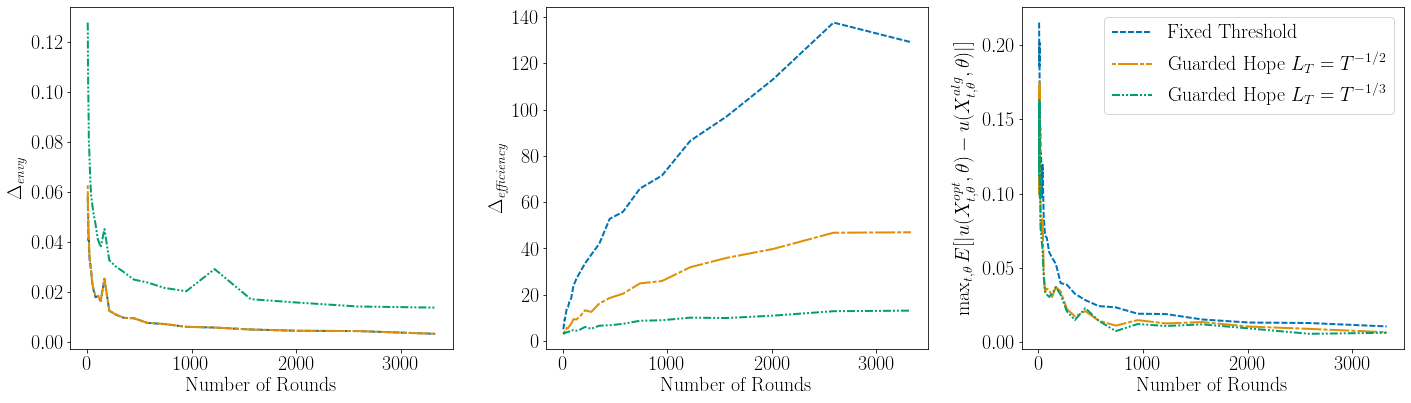

In [12]:
df = pd.DataFrame.from_records(data)

df.columns
df = df.assign(Algorithm = lambda df: df.Algorithm.replace({'fixed_threshold': 'Fixed Threshold', 'hope_guardrail_13': 'Guarded Hope $L_T = T^{-1/3}$', 'hope_guardrail_12': 'Guarded Hope $L_T = T^{-1/2}$'}))

plt.style.use('PaperDoubleFig.mplstyle.txt')
# Make some style choices for plotting 
# colorWheel =['#2bd1e5',
#             '#281bf5',
#              '#db1bf5',
#              '#F5CD1B',
#             '#FF5733','#9cf51b',]
dashesStyles = [[3,1],
            [2,1,10,1],
            [4, 1, 1, 1, 1, 1]] #[1000,1],[8,2]]

print(df.head)


#filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
#plt.figure(figsize=(20,10))
#plt.title('Simple Distribution L1')
#sns.lineplot(x='NumGroups', y='value', hue='variable', data=df[df.Norm == 'L1'])

filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
dash_styles = ["",
               (4, 1.5),
               (1, 1),
               (3, 1, 1.5, 1),
               (5, 1, 1, 1),
               (5, 1, 2, 1, 2, 1),
               (2, 2, 3, 1.5),
               (1, 2.5, 3, 1.2)]

# fig = plt.figure(figsize=(20,6))
plt.rc('text', usetex=True)



fg, axs = plt.subplots(1,3, sharex='all', figsize=(20,6))
sns.lineplot(x='NumGroups', y='Value', hue='Algorithm', style = 'Algorithm', dashes = dashesStyles,
                     data=df[df.Norm == 'Envy'], ax = axs[0], palette = sns.color_palette("colorblind", 3),
            ci = None)
sns.lineplot(x='NumGroups', y='Value', hue='Algorithm', style = 'Algorithm', dashes = dashesStyles, 
             data=df[df.Norm == 'Waste'], ax = axs[1], palette = sns.color_palette("colorblind", 3),
            ci = None)

sns.lineplot(x='NumGroups', y='Value', hue='Algorithm', style = 'Algorithm', dashes = dashesStyles, 
             data=df[df.Norm == 'Ex-Ante Envy'], ax = axs[2], palette = sns.color_palette("colorblind", 3),
            ci = None)



axs[0].get_legend().remove()
axs[0].set_ylabel('$\Delta_{\it envy}$')
axs[0].set_xlabel('Number of Rounds')

axs[1].set_ylabel('$\Delta_{\it efficiency}$')
axs[1].set_xlabel('Number of Rounds')
axs[1].get_legend().remove()

axs[2].get_legend().remove()
axs[2].set_ylabel(r'$\max_{t, \theta} E[|u(X^{opt}_{t, \theta}, \theta) - u(X^{alg}_{t, \theta}, \theta)|]$')
axs[2].set_xlabel('Number of Rounds')


axs[2].legend(ncol = 1, loc= 'upper right')




plt.show()
# fg.savefig('multi_poisson.pdf', bbox_inches = 'tight',pad_inches = 0.01, dpi=900)


### Group by Group Difference

In [19]:
fair_data = []
num_types = 5





num_resources = 3
weights = np.asarray([[1, 2, 3], [1, 3, 2], [4, 1, 5], [1, 2, .5], [3, 7, 5]])
sum_of_rows = weights.sum(axis=1)
weights = weights / sum_of_rows[:, np.newaxis]

algo_list = [fixed_threshold, hope_guardrail_12, hope_guardrail_13]
num_algo = len(algo_list)
# algo_list = [fixed_threshold]

num_iterations = 5
max_n = 100

# mean_size = np.asarray([1, 3, 6, 2, 5])
# dist_weights = [1/5, 1/5, 1/5, 1/5, 1/5]
mean_size = np.asarray([1.5, 1.5, 1.5, 1.5, 1.5])





for i in tqdm(range(num_iterations)):
    budget = [n, n, n]
    
    mean = np.array([mean_size,]*n)
    # print(mean)

    # size = np.random.choice(size=n, a=[1.,2.], p=[1/2, 1/2])
    size = np.random.choice(size=(n, num_types), a=[1.,2.], p=[1/2, 1/2])
    # print('Size: ' + str(size))
    total_num_types = np.sum(size, axis=0)

    prob, solver = generate_cvxpy_solve(num_types, num_resources)


    # print(num_types, num_resources, budget.shape size.shape, )

    future_size = size[0] + np.sum(mean[1:], axis=0)

    lower_exp_size = future_size*(1 +  np.max(np.sqrt(mean_size*n) / future_size))
    _, lower_sol = solver(lower_exp_size, weights, budget)

    c = (1 / (n**(1/2)))*(1 +  np.max(np.sqrt(mean_size*n) / future_size)) -  np.max(np.sqrt(mean_size*n) / future_size)
    print(c)
    upper_exp_size_12 = future_size*(1 - c)
    _, upper_sol_12 = solver(upper_exp_size_12, weights, budget)

    c = (1 / (n**(1/3)))*(1 +  np.max(np.sqrt(mean_size*n) / future_size)) -  np.max(np.sqrt(mean_size*n) / future_size)
    print(c)
    upper_exp_size_13 = future_size*(1 - c)
    _, upper_sol_13 = solver(upper_exp_size_13, weights, budget)
    
    opt = offline_opt(budget, size, weights, solver)

    # print('opt: ' + str(opt))
    for algo in algo_list:
        if algo.__name__ == 'hope_guardrail_12':
            upper_sol = upper_sol_12
        else:
            upper_sol = upper_sol_13
        sol, waste = algo(budget, size, mean, weights, solver, lower_sol, upper_sol)
        prop_alloc = budget / np.sum(size)   
        true_envy = 0
        proportional = 0
        
        
        for k in range(num_types):
            proportional = max(proportional, max(np.dot(weights[k, :], prop_alloc) - np.matmul(sol[:,k,:], weights[k,:])))
        
        for k1 in range(num_types):
            for k2 in range(num_types):
                true_envy = max(envy, max(np.matmul(sol[:,k2,:], weights[k1, :])) - min(np.matmul(sol[:,k1,:], weights[k1,:])))
           
        envy = 0
        for k in range(num_types):
            for t in range(n):
                envy = max(envy, np.abs(np.dot(weights[k, :], opt[t, k, :] - sol[t, k, :])))
        fair_data.append({'Iteration':i, 'Algorithm':algo.__name__, 'Waste':np.sum(waste) / n, 'True Envy': true_envy, 'Envy': envy, 'Proportional':proportional})
            
for i in range(n):
    data.append({'Location': i, 'Algorithm':'Zero', 'Value': 0})

  0%|          | 0/5 [00:00<?, ?it/s]

0.0034237650666050622
0.053762601519859246
0.0034237650666050622
0.053762601519859246
0.0034237650666050622
0.053762601519859246
0.0034237650666050622
0.053762601519859246
0.0034237650666050622
0.053762601519859246


In [20]:
fair_df_2 = pd.DataFrame.from_records(fair_data)
fair_df_2['Proportional']

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
Name: Proportional, dtype: int64

In [ ]:
fair_df_2.head

### Printing Fairness Metrics

In hindsight proportional as the same makes sense, as it will be achieved by people obtaining X_lower, which is the same for all the algorithms (and algorithms ensure they don't run out of budget....)

                      Waste  True Envy      Envy  Proportional
Algorithm                                                     
fixed_threshold    0.049511   0.011032  0.003798             0
hope_guardrail_12  0.018503   0.003798  0.003798             0
hope_guardrail_13  0.004108   0.009752  0.012903             0


In [36]:
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections.polar import PolarAxes
from matplotlib.projections import register_projection
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D


def radar_factory(num_vars, frame='circle'):
    """Create a radar chart with `num_vars` axes.

    This function creates a RadarAxes projection and registers it.

    Parameters
    ----------
    num_vars : int
        Number of variables for radar chart.
    frame : {'circle' | 'polygon'}
        Shape of frame surrounding axes.

    """
    # calculate evenly-spaced axis angles
    theta = np.linspace(0, 2*np.pi, num_vars, endpoint=False)

    class RadarAxes(PolarAxes):

        name = 'radar'

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            # rotate plot such that the first axis is at the top
            self.set_theta_zero_location('N')

        def fill(self, *args, closed=True, **kwargs):
            """Override fill so that line is closed by default"""
            return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            """Override plot so that line is closed by default"""
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)

        def _close_line(self, line):
            x, y = line.get_data()
            # FIXME: markers at x[0], y[0] get doubled-up
            if x[0] != x[-1]:
                x = np.concatenate((x, [x[0]]))
                y = np.concatenate((y, [y[0]]))
                line.set_data(x, y)

        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)

        def _gen_axes_patch(self):
            # The Axes patch must be centered at (0.5, 0.5) and of radius 0.5
            # in axes coordinates.
            if frame == 'circle':
                return Circle((0.5, 0.5), 0.5)
            elif frame == 'polygon':
                return RegularPolygon((0.5, 0.5), num_vars,
                                      radius=.5, edgecolor="k")
            else:
                raise ValueError("unknown value for 'frame': %s" % frame)

        def draw(self, renderer):
            """ Draw. If frame is polygon, make gridlines polygon-shaped """
            if frame == 'polygon':
                gridlines = self.yaxis.get_gridlines()
                for gl in gridlines:
                    gl.get_path()._interpolation_steps = num_vars
            super().draw(renderer)


        def _gen_axes_spines(self):
            if frame == 'circle':
                return super()._gen_axes_spines()
            elif frame == 'polygon':
                # spine_type must be 'left'/'right'/'top'/'bottom'/'circle'.
                spine = Spine(axes=self,
                              spine_type='circle',
                              path=Path.unit_regular_polygon(num_vars))
                # unit_regular_polygon gives a polygon of radius 1 centered at
                # (0, 0) but we want a polygon of radius 0.5 centered at (0.5,
                # 0.5) in axes coordinates.
                spine.set_transform(Affine2D().scale(.5).translate(.5, .5)
                                    + self.transAxes)


                return {'polar': spine}
            else:
                raise ValueError("unknown value for 'frame': %s" % frame)

    register_projection(RadarAxes)
    return theta

def normalize(df):
    result = df.copy()
    for feature_name in df.columns:
        max_value = df[feature_name].max()
        min_value = df[feature_name].min()
        result[feature_name] = (df[feature_name] - min_value) / (max_value - min_value)
                
    return result

In [40]:
fair_df = pd.DataFrame.from_records(fair_data)
fair_df = fair_df.assign(Algorithm = lambda df: df.Algorithm.replace({'fixed_threshold': 'Fixed Threshold', 'hope_guardrail_13': 'Guarded Hope $L_T = T^{-1/3}$', 'hope_guardrail_12': 'Guarded Hope $L_T = T^{-1/2}$'}))

# print(fair_df.columns)
fair_df = fair_df.groupby(['Algorithm']).mean()
print(fair_df.drop(['Iteration'], axis=1))

                                  Waste  True Envy      Envy  Proportional
Algorithm                                                                 
Fixed Threshold                0.049511   0.011032  0.003798             0
Guarded Hope $L_T = T^{-1/2}$  0.018503   0.003798  0.003798             0
Guarded Hope $L_T = T^{-1/3}$  0.004108   0.009752  0.012903             0


In [41]:
fair_df = normalize(fair_df).drop(['Iteration'], axis=1)

print(fair_df)

                                  Waste  True Envy  Envy  Proportional
Algorithm                                                             
Fixed Threshold                1.000000   1.000000   0.0           NaN
Guarded Hope $L_T = T^{-1/2}$  0.317063   0.000000   0.0           NaN
Guarded Hope $L_T = T^{-1/3}$  0.000000   0.823048   1.0           NaN


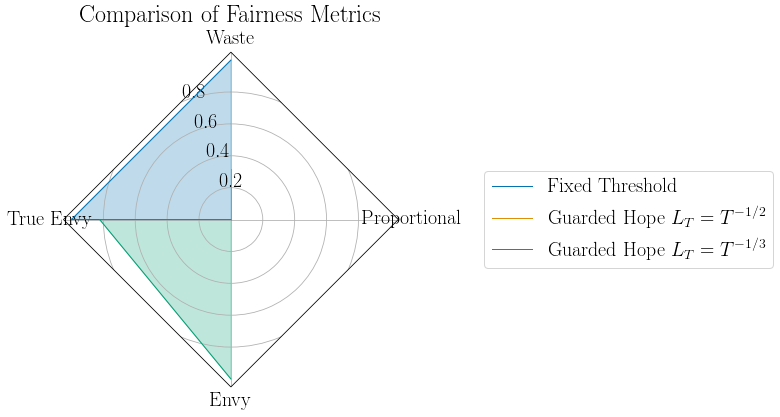

In [42]:
# number of variable



plt.style.use('PaperDoubleFig.mplstyle.txt')


from math import pi


plt.rc('text', usetex=True)




N = len(list(fair_df))
theta = radar_factory(N, frame='polygon')

spoke_labels = list(fair_df)

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection='radar'))
fig.subplots_adjust(top=0.85, bottom=0.05)

ax.set_rgrids([0.2, 0.4, 0.6, 0.8])
ax.set_title('Comparison of Fairness Metrics',  position=(0.5, 1.1), ha='center')

index = 0
for algo in algo_list:
    values = fair_df.iloc[index, :].to_numpy()
    ax.plot(theta, values, linewidth=1, linestyle='solid', label=fair_df.index[index], color = sns.color_palette('colorblind', len(algo_list))[index])
    ax.fill(theta, values, color = sns.color_palette('colorblind', len(algo_list))[index],  alpha=0.25)
    index += 1
ax.set_varlabels(spoke_labels)

plt.legend(loc='right', bbox_to_anchor=(2.15, .5))

plt.show()
# plt.savefig('radar.pdf')



